# Aplicando o algoritmo PSO em diversas funções

O objetivo desse notebook é implementar o algoritmo em mais 6 funções a fim de comparar o desempenho e possibilitar o *benchmarking* com outros algoritmos.

**Autor:** Edélio Gabriel Magalhães de Jesus.

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/ec/ParticleSwarmArrowsAnimation.gif" alt="PSO Animation" width="500">
</p>

<p align="center">
  <em>Fonte: <a href="https://en.wikipedia.org/wiki/Particle_swarm_optimization">Wikipédia - Particle Swarm Optimization</a></em>
</p>

## Introdução

A **Otimização por Enxame de Partículas** (do inglês *Particle Swarm Optimization*, ou simplesmente **PSO**) é um método computacional de otimização baseado em população, inspirado no comportamento social de bandos de pássaros e cardumes de peixes [[1]](#ref-paper-original). Proposto originalmente por Kennedy e Eberhart em 1995, o PSO busca melhorar iterativamente um conjunto de soluções candidatas com base em uma métrica de qualidade — a função objetivo [[1]](#ref-paper-original).

Cada solução candidata é denominada **partícula**, e o conjunto de todas as partículas forma o **enxame**. Cada partícula $i$ é caracterizada por dois vetores no espaço de busca $\mathbb{R}^d$:

- $\mathbf{x}_i \in \mathbb{R}^d$: sua **posição atual**  
- $\mathbf{v}_i \in \mathbb{R}^d$: sua **velocidade atual**

A cada iteração $t$, a velocidade e a posição de cada partícula são atualizadas pelas seguintes equações [[2]](#ref-shi-eberhart):

$$
\mathbf{v}_i(t+1) = \omega \, \mathbf{v}_i(t) + c_1 r_1 \left(\mathbf{p}_i - \mathbf{x}_i(t)\right) + c_2 r_2 \left(\mathbf{g} - \mathbf{x}_i(t)\right)
$$

$$
\mathbf{x}_i(t+1) = \mathbf{x}_i(t) + \mathbf{v}_i(t+1)
$$

onde:

| Símbolo | Descrição |
|---|---|
| $\omega$ | Fator de inércia — controla a influência da velocidade anterior |
| $c_1$ | Coeficiente cognitivo — peso da experiência individual da partícula |
| $c_2$ | Coeficiente social — peso da experiência coletiva do enxame |
| $r_1, r_2$ | Números aleatórios uniformes em $[0, 1]$ — introduzem estocasticidade |
| $\mathbf{p}_i$ | Melhor posição já visitada pela partícula $i$ (*personal best*) |
| $\mathbf{g}$ | Melhor posição já visitada por qualquer partícula do enxame (*global best*) |

O movimento de cada partícula é, portanto, influenciado por três componentes: a **inércia** (tendência de manter a direção atual), o **componente cognitivo** (atração em direção à sua melhor posição individual) e o **componente social** (atração em direção à melhor posição do enxame). Os vetores $\mathbf{p}_i$ e $\mathbf{g}$ são atualizados sempre que posições melhores são encontradas ao longo das iterações [[2]](#ref-shi-eberhart).

## Módulo para implementação do algoritmo

Neste *notebook* usaremos o módulo `pyswarms` [[3]](#ref-pyswarms), desenvolvido por Lester James V. Miranda.
A escolha foi baseada na aderência ao algoritmo clássico proposto por Kennedy & Eberhart (1995) [[1]](#ref-paper-original), com suporte nativo a múltiplas topologias de vizinhança e hiperparâmetros ajustáveis.


In [1]:
import numpy as np
import pyswarms as ps
from pyswarms.single import GlobalBestPSO

### **Função para aplicar o algoritmo**

In [2]:
def run_pso(function, x_min, x_max, dim, max_evals, seed=367,
            w=0.7, c1=1.5, c2=1.5):
    """
    Executa o PSO para uma função objetivo.

    Parâmetros
    ----------
    function : callable
        Função objetivo a ser minimizada. Deve aceitar um array (n_particles, dim).
    x_min : float
        Limite inferior do espaço de busca.
    x_max : float
        Limite superior do espaço de busca.
    dim : int
        Dimensionalidade do problema.
    max_evals : int
        Número máximo de avaliações da função objetivo.
    seed : int
        Semente para reprodutibilidade.
    w : float
        Fator de inércia — controla a influência da velocidade anterior.
    c1 : float
        Coeficiente cognitivo — peso da experiência individual da partícula.
    c2 : float
        Coeficiente social — peso da experiência coletiva do enxame.

    Retorna
    -------
    best : float
        Melhor valor encontrado.
    evals : int
        Número de avaliações realizadas.
    historico : list[float]
        Melhor valor por iteração.
    """
    np.random.seed(seed)

    # Tamanho da população seguindo a convenção da literatura
    # Shi & Eberhart (1998) recomendam entre 20 e 50 partículas
    n_particles = 20
    n_iters = max_evals // n_particles

    bounds = (
        np.full(dim, x_min),
        np.full(dim, x_max)
    )

    options = {'c1': c1, 'c2': c2, 'w': w}

    # Wrapper vetorizado: pyswarms passa (n_particles, dim)
    def objective(X):
        return np.array([function(x) for x in X])

    optimizer = GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dim,
        options=options,
        bounds=bounds
    )

    for _ in range(n_iters):
        optimizer.optimize(objective, iters=1, verbose=False)

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iters,
        verbose=False
    )

    historico = optimizer.cost_history
    evals = n_particles * (n_iters + 1)  # conta avaliação inicial

    return best_cost, evals, historico

`NOTAS`

`n_particles`: Dado a necessidade de reprodutibilidade e escalabilidade, definiu-se o tamanho do enxame como

```python
    n_particles = min(30, max(10, 10 + int(2 * np.log(dim)))),
```

uma adaptação da recomendação de Shi & Eberhart (1998) [[2]](#ref-shi-eberhart), que sugerem entre 20 e 50 partículas para a maioria dos problemas.

`n_iters`: O número de iterações é derivado do orçamento de avaliações como `max_evals // n_particles`, garantindo comparabilidade com os outros algortimos.

## Função para *plotar* gráfico

In [3]:
from plot_painel_functions import plot_painel, plot_painel_dimensional

## Funções de análise

Para esse *notebook*, foram elencadas as mesmas 5 funções do *benchmark* com CMA, separadas nas seguintes classes:

`Muitos mínimos locais`

- Levy
- Rastrigin
- Schwefel

`Forma de vale`:

- Rosenbrock

`Convexa`:

- Sphere

A partir desses casos, podemos construir uma boa fundamentação para comparar o PSO com o CMA e outros algoritmos de otimização *derivative-free*.

---

Vamos definir alguns parâmetros gerais

In [4]:
SEED = 367
dims = [5, 10, 20, 50, 100]
max_evals = 5000
n_iter = 100

`NOTA`:

Os intervalos de amostragem serão definidos conforme a especificidade de cada função, tendo como base a referência [[4]](#ref-library).

---

### **Função: Levy**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/levy.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sin^2(\pi w_1) + \sum_{i=1}^{d-1}(w_i - 1)^2[1+ 10\sin^2(\pi w_i + 1)] + (w_d - 1)^2[1 + \sin^2(2\pi w_d)]
$$

onde

$$
w_i = 1 + \frac{x_i -1}{4}
$$

para $i = 1, ..., d$.

In [5]:
def levy(x):
    x = np.asarray(x, dtype=float)
    w = 1 + (x - 1) / 4

    term1 = np.sin(np.pi * w[0])**2

    term2 = np.sum(
        (w[:-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:-1] + 1)**2)
    )

    term3 = (w[-1] - 1)**2 * (1 + np.sin(2 * np.pi * w[-1])**2)

    return term1 + term2 + term3

In [6]:
hist_levy = {}

for dim in dims:
    hist_dim = []

    for i in range(n_iter):
        seed = SEED + i

        best, evals, hist = run_pso(
            function=levy,
            x_min=-10, x_max=10,
            dim=dim,
            max_evals=max_evals,
            seed=seed
        )

        hist_dim.append(hist)

    hist_levy[dim] = np.array(hist_dim)

In [7]:
len(hist_levy[20])

100

---

``Vamos plotar os resultados``

---

Primeiro, escolheremos os dados coletados para uma dimensão fixada. Para essa e as demais análises, escolheremos a otimização para 20 dimensões.

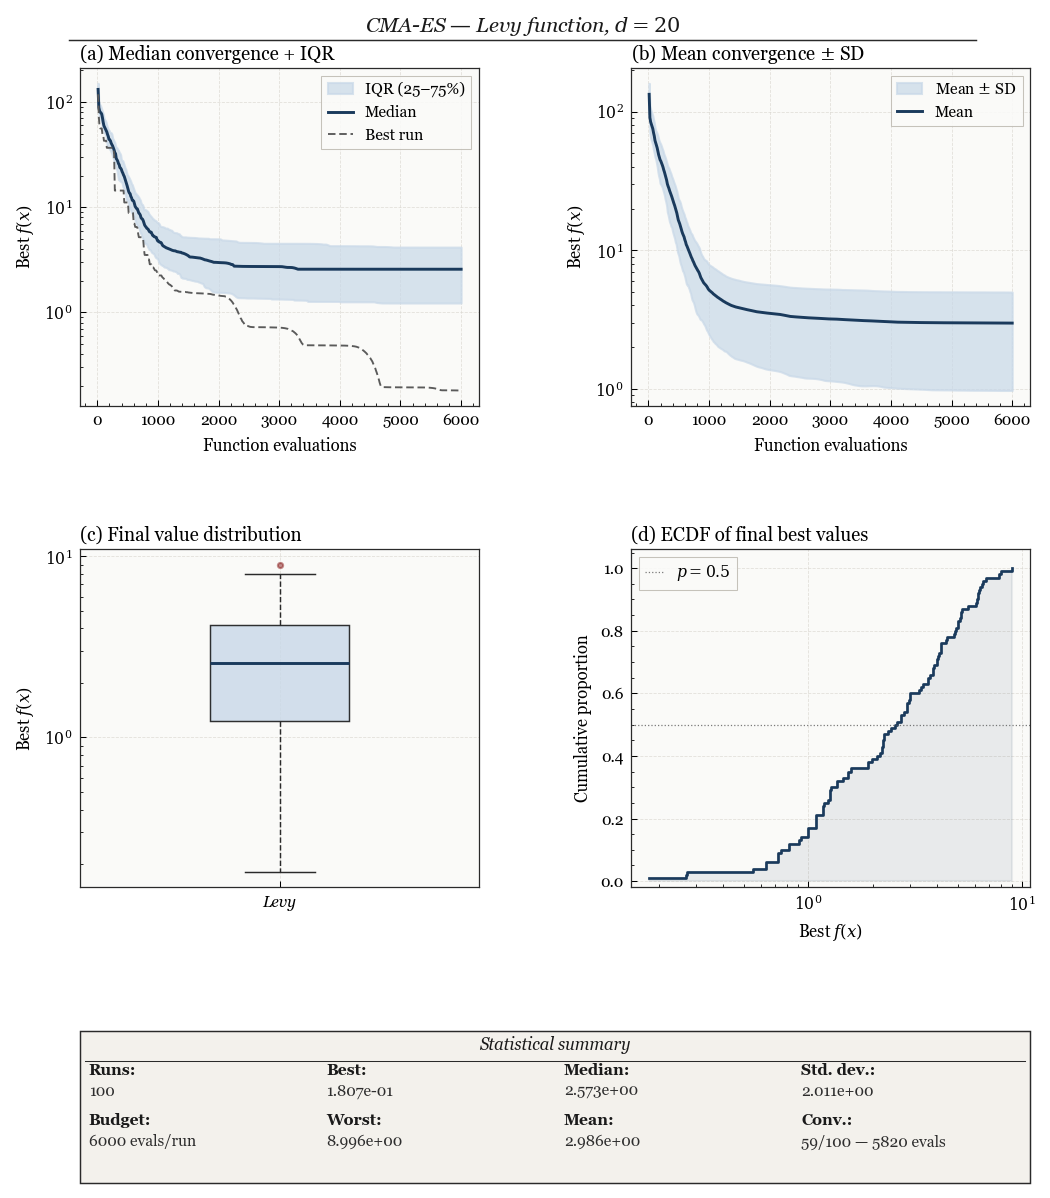

In [8]:
plot_painel(hist_levy[20], func='Levy', dim=20)

Agora, olharemos para como o algoritmo se comporta quando escalamos o número de dimensões.

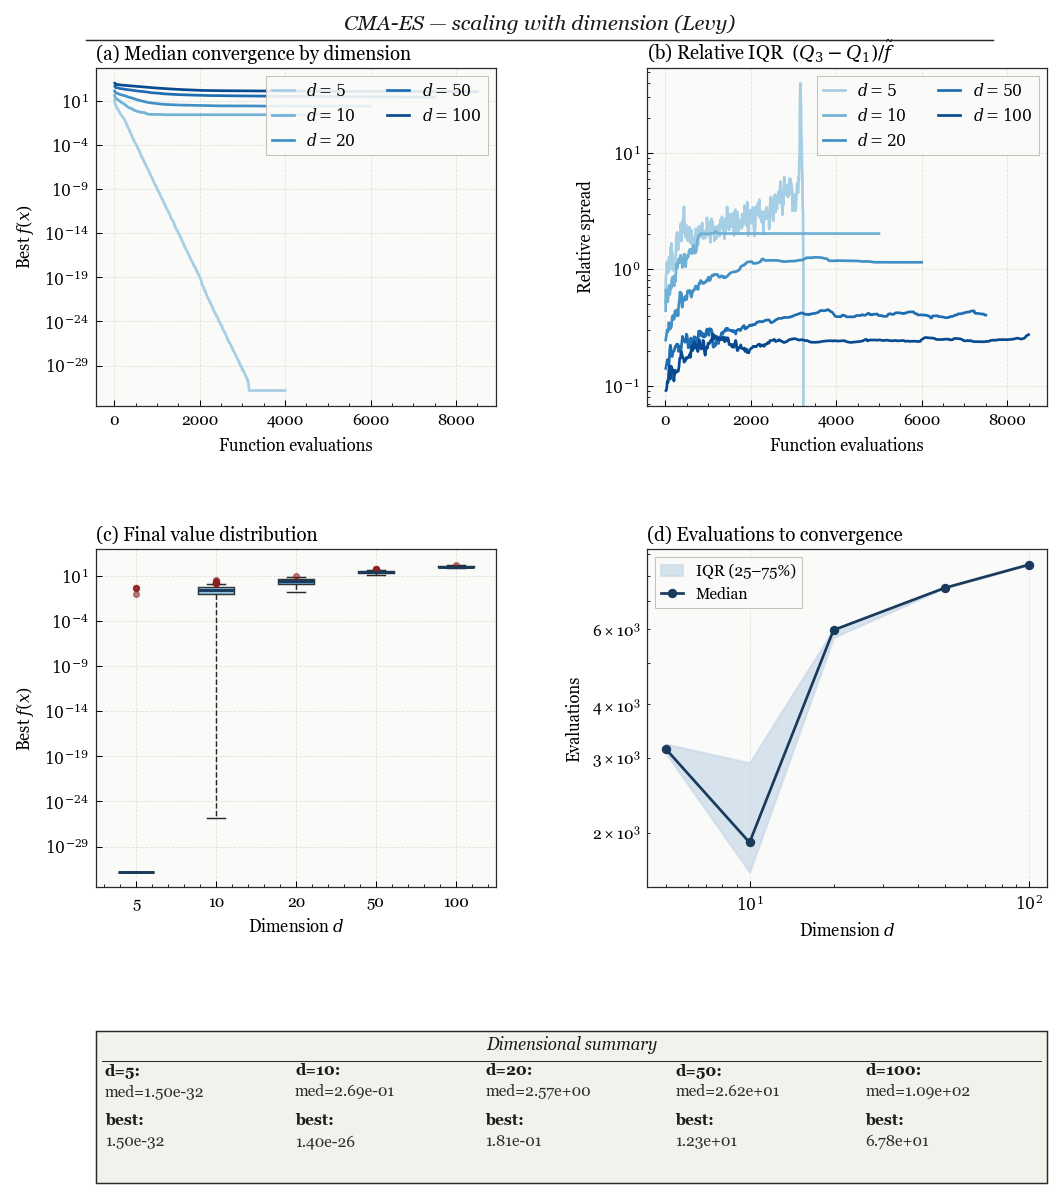

In [9]:
plot_painel_dimensional(hist_levy, func='Levy')

### **Função Rastrigin**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/rastr.png" alt="Função de Rastrigin" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = 10d + \sum_{i=1}^d[x_i^2 - 10\cos(2\pi x_i)]
$$

In [10]:
def rastrigin(x):
    x = np.asarray(x, dtype=float)
    d = len(x)

    return (
        10 * d + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x))
    )

In [11]:
hist_rastrigin = {}

for dim in dims:
    hist_dim = []

    for i in range(n_iter):
        seed = SEED + i

        best, evals, hist = run_pso(
            function=rastrigin,
            x_min=-5.12, x_max=5.12,
            dim=dim,
            max_evals=max_evals,
            seed=seed
        )

        hist_dim.append(hist)

    hist_rastrigin[dim] = np.array(hist_dim)

---

Vamos visualizar os resultados

---

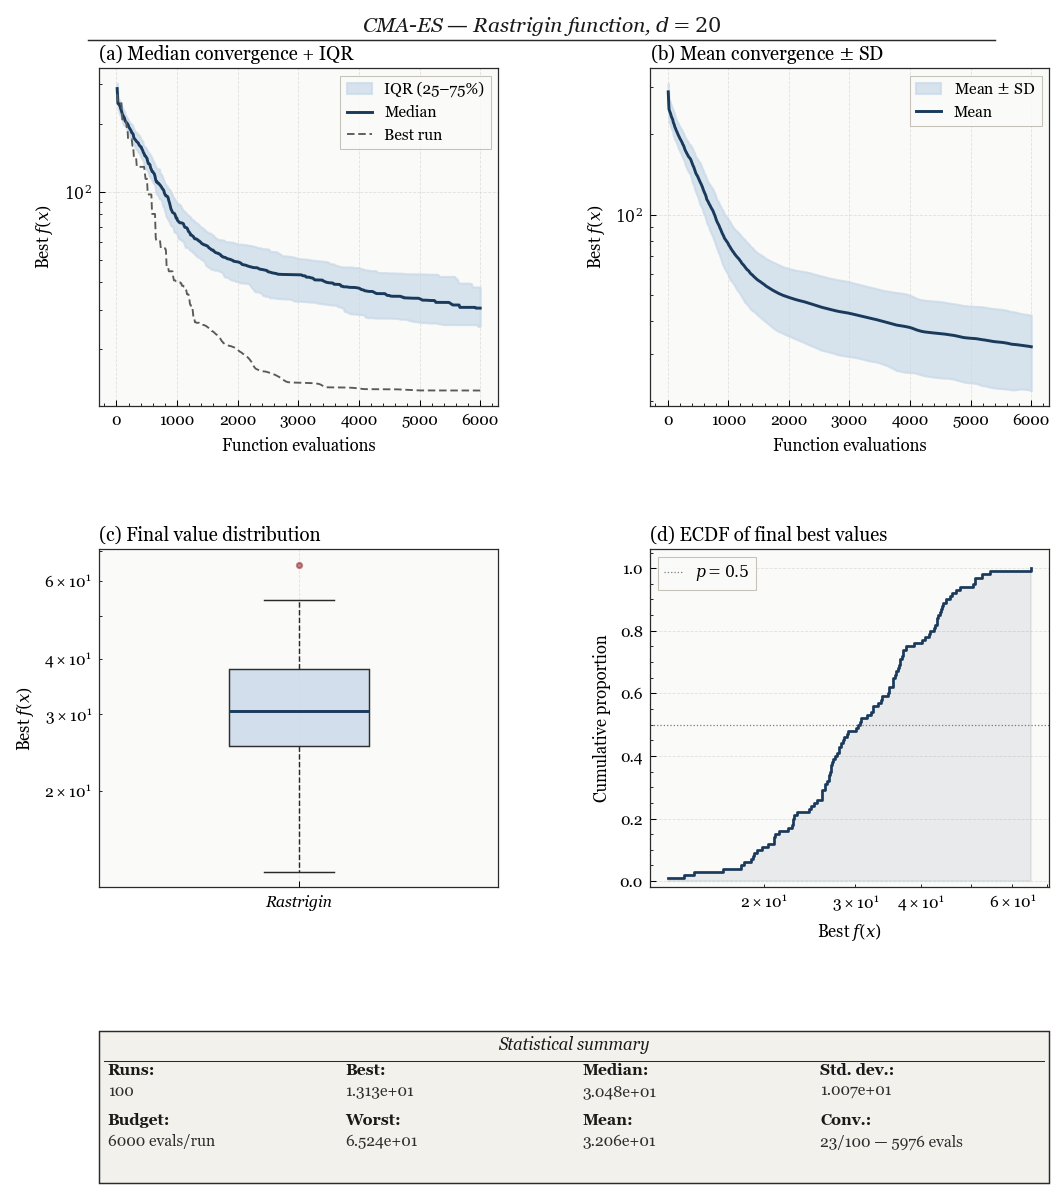

In [12]:
plot_painel(hist_rastrigin[20], func='Rastrigin', dim=20)

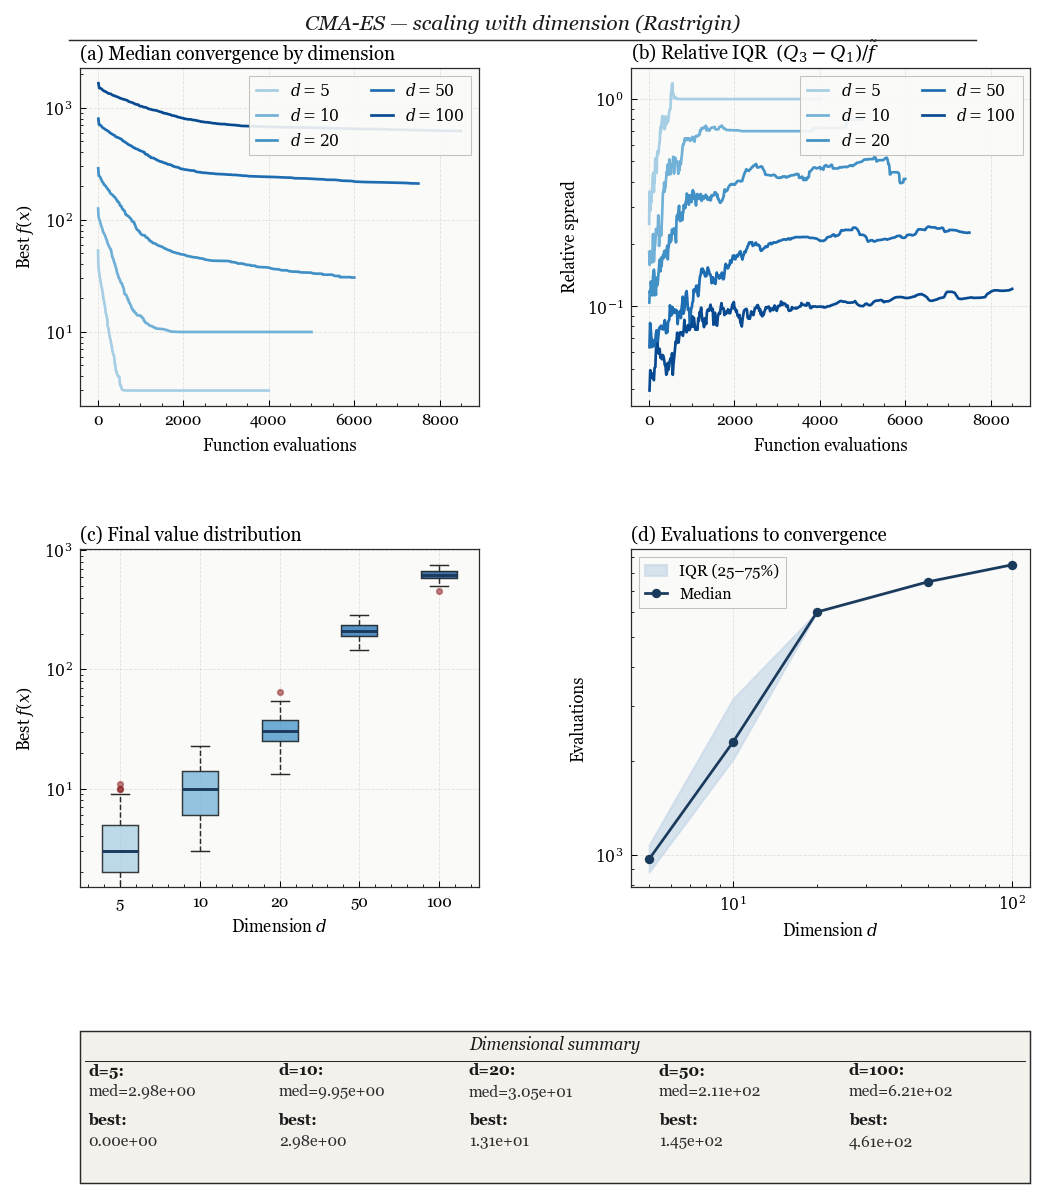

In [13]:
plot_painel_dimensional(hist_rastrigin, func='Rastrigin')

### **Função Schwefel**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/schwef.png" alt="Função de Schwefel" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = 418.9829d - \sum_{i=1}^dx_i\sin\left(\sqrt{|x_i|}\right)
$$

In [14]:
def schwefel(x):
    x = np.asarray(x, dtype=float)
    d = x.size

    return 418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

In [15]:
hist_schwefel = {}

for dim in dims:
    hist_dim = []

    for i in range(n_iter):
        seed = SEED + i

        best, evals, hist = run_pso(
            function=schwefel,
            x_min=-500, x_max=500,
            dim=dim,
            max_evals=max_evals,
            seed=seed
        )

        hist_dim.append(hist)

    hist_schwefel[dim] = np.array(hist_dim)

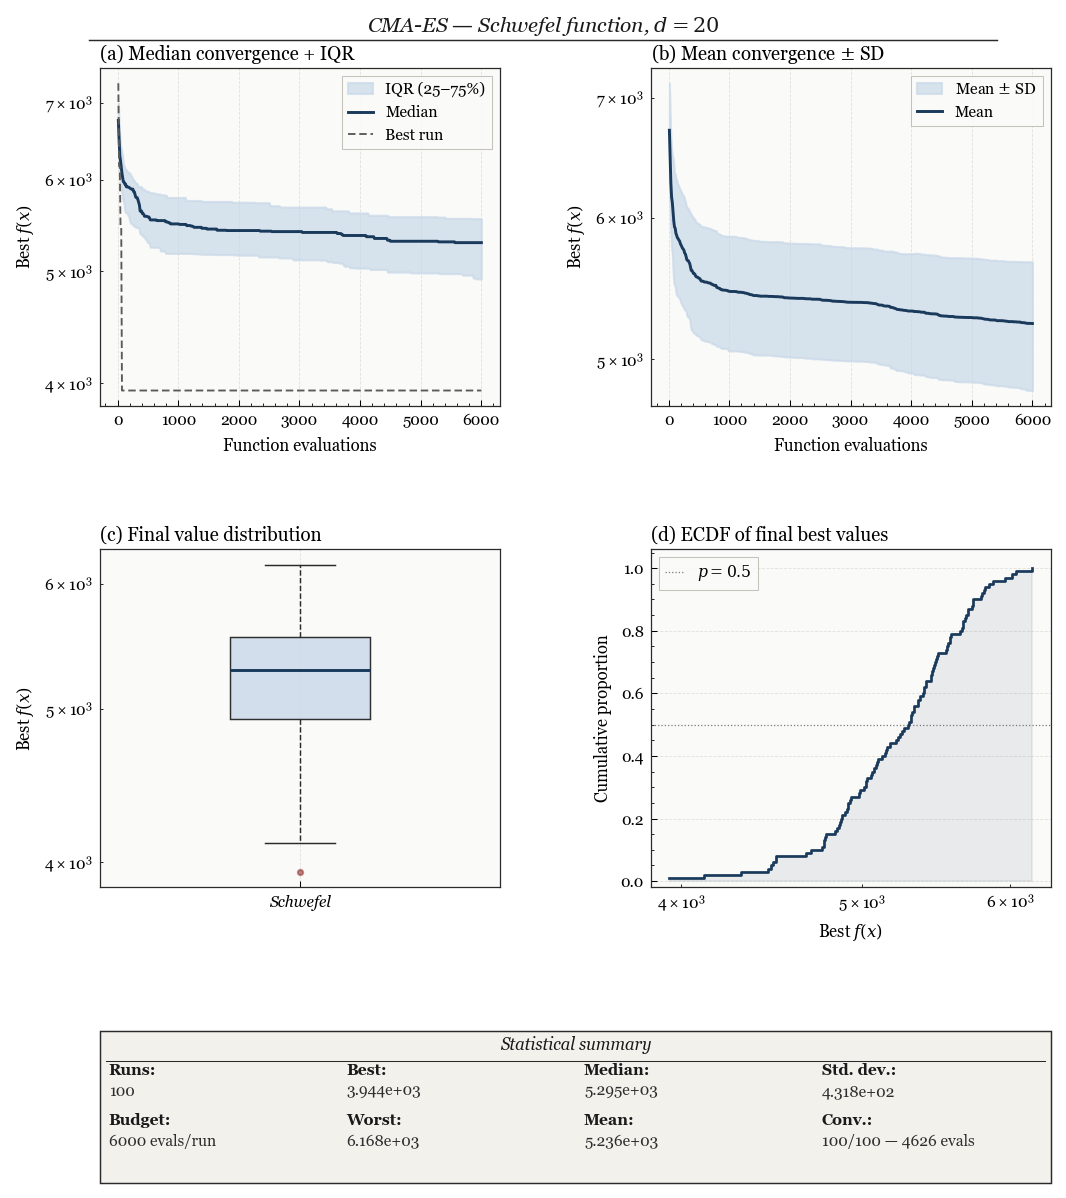

In [16]:
plot_painel(hist_schwefel[20], func='Schwefel', dim=20)

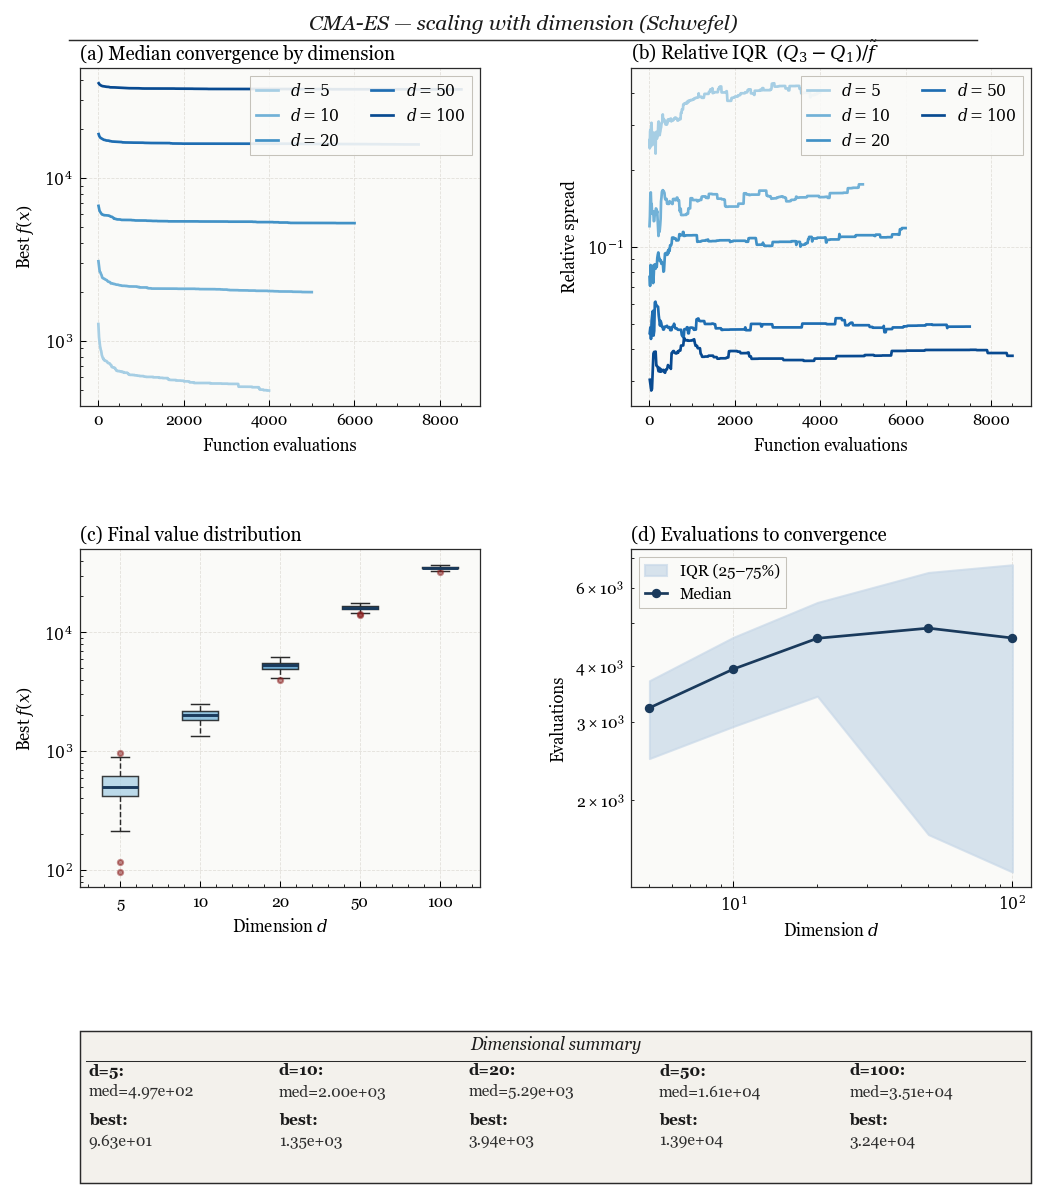

In [17]:
plot_painel_dimensional(hist_schwefel, func='Schwefel')

### **Função Rosenbrock**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/rosen.png" alt="Função de Rosenbrock" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sum_{i=1}^{d-1}[100(x_{i+1} - x_i^2)^2 + (x_i -1)^2]
$$

In [18]:
def rosenbrock(x):
    x = np.array(x)

    return np.sum(
        100 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2
    )

---

Adivinha? Vamos olhar os resultados!

---

In [19]:
hist_rosenbrock = {}

for dim in dims:
    hist_dim = []

    for i in range(n_iter):
        seed = SEED + i

        best, evals, hist = run_pso(
            function=rosenbrock,
            x_min=-2.048, x_max=2.048,
            dim=dim,
            max_evals=max_evals,
            seed=seed
        )

        hist_dim.append(hist)

    hist_rosenbrock[dim] = np.array(hist_dim)

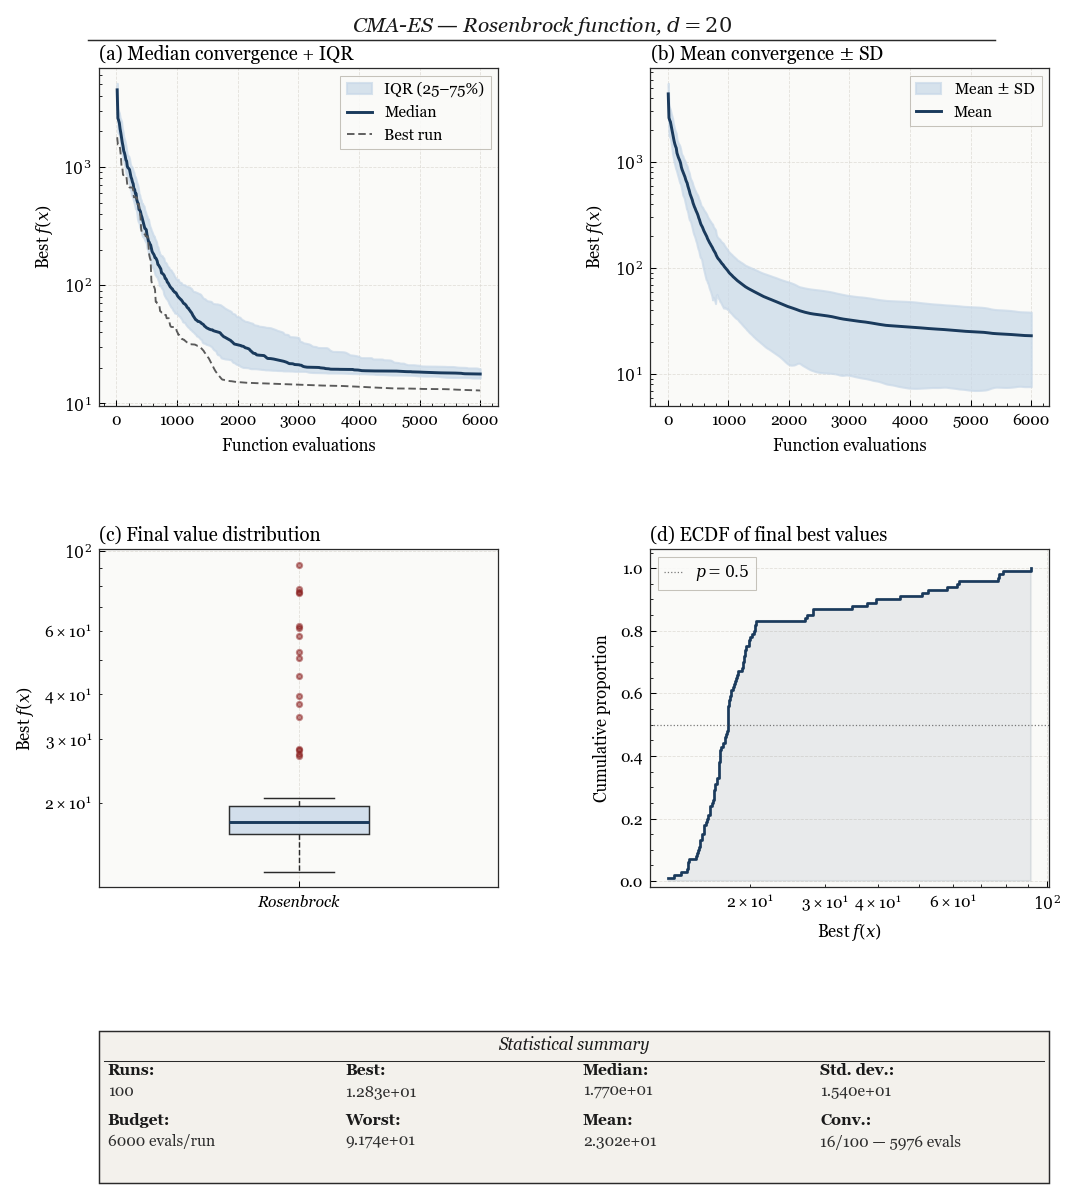

In [20]:
plot_painel(hist_rosenbrock[20], func='Rosenbrock', dim=20)

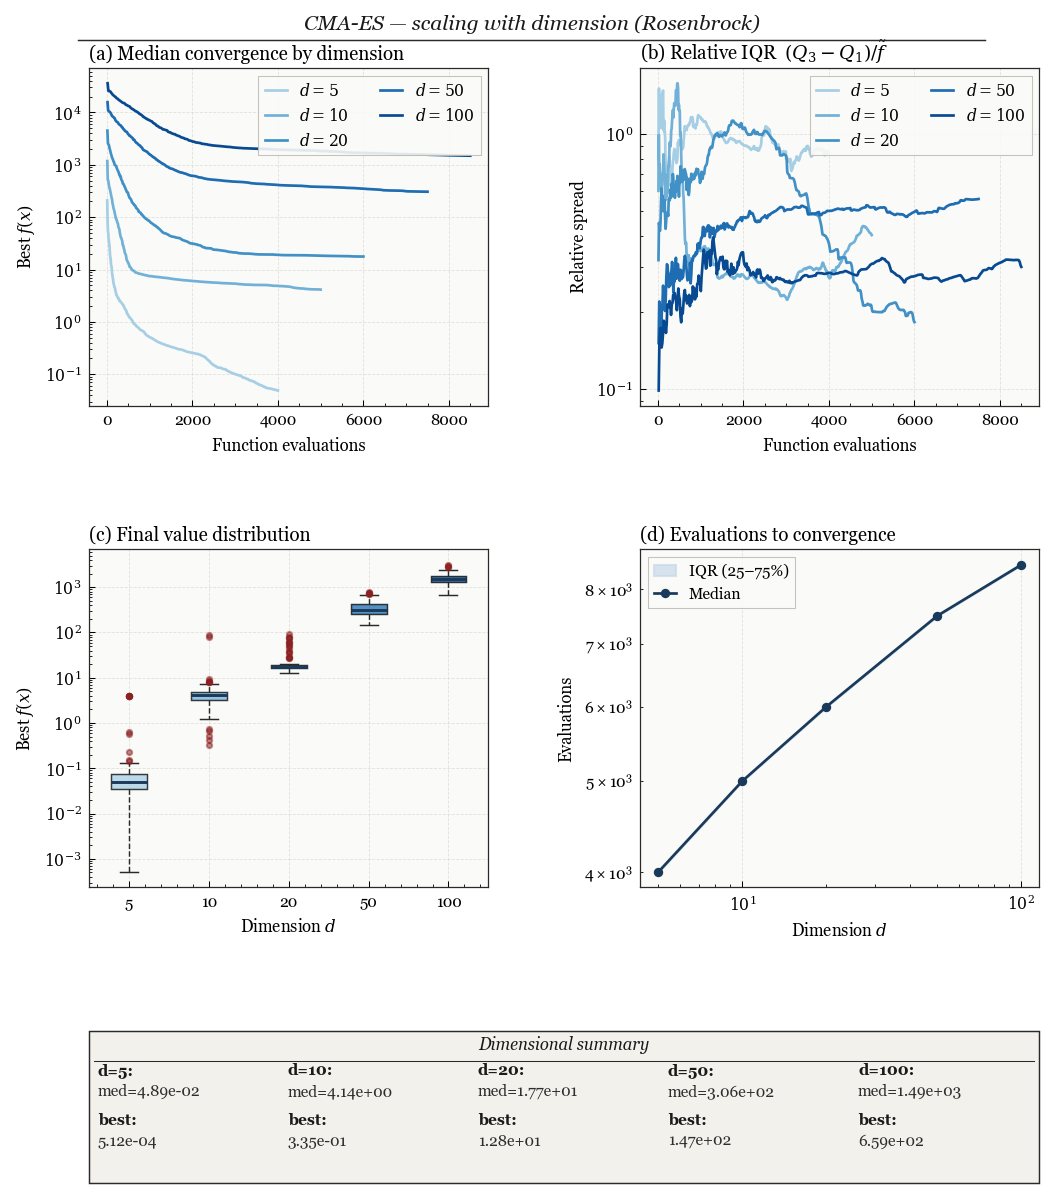

In [21]:
plot_painel_dimensional(hist_rosenbrock, func='Rosenbrock')

### **Função Sphere**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/spheref.png" alt="Função Sphere" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sum_{i=1}^dx_i^2
$$

In [22]:
def sphere(x):
    x = np.asarray(x, dtype=float)

    return np.sum(x**2)

In [23]:
hist_sphere = {}

for dim in dims:
    hist_dim = []

    for i in range(n_iter):
        seed = SEED + i

        best, evals, hist = run_pso(
            function=sphere,
            x_min=-5.12, x_max=5.12,
            dim=dim,
            max_evals=max_evals,
            seed=seed
        )

        hist_dim.append(hist)

    hist_sphere[dim] = np.array(hist_dim)

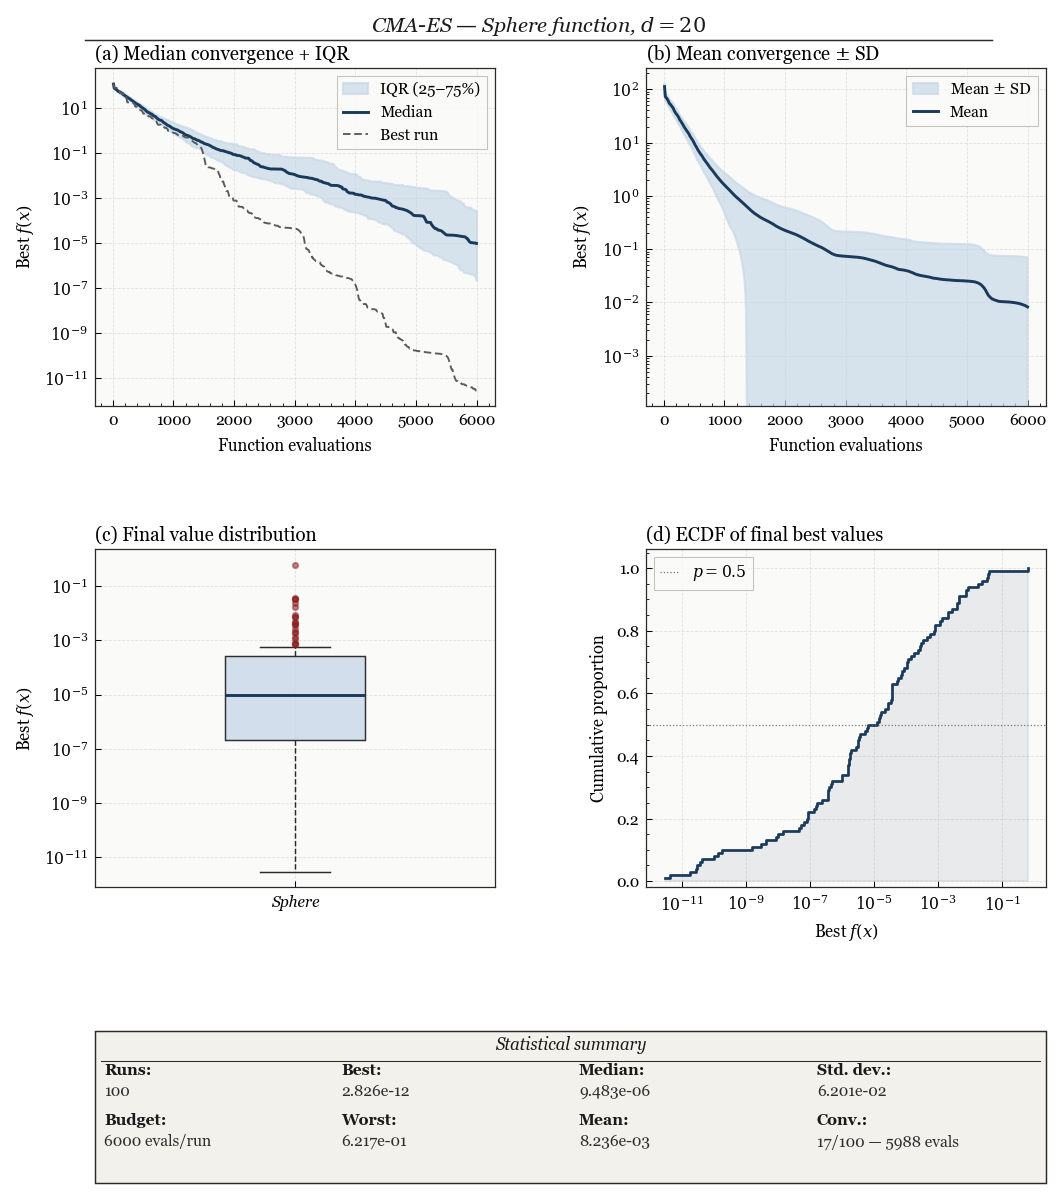

In [24]:
plot_painel(hist_sphere[20], func='Sphere', dim=20)

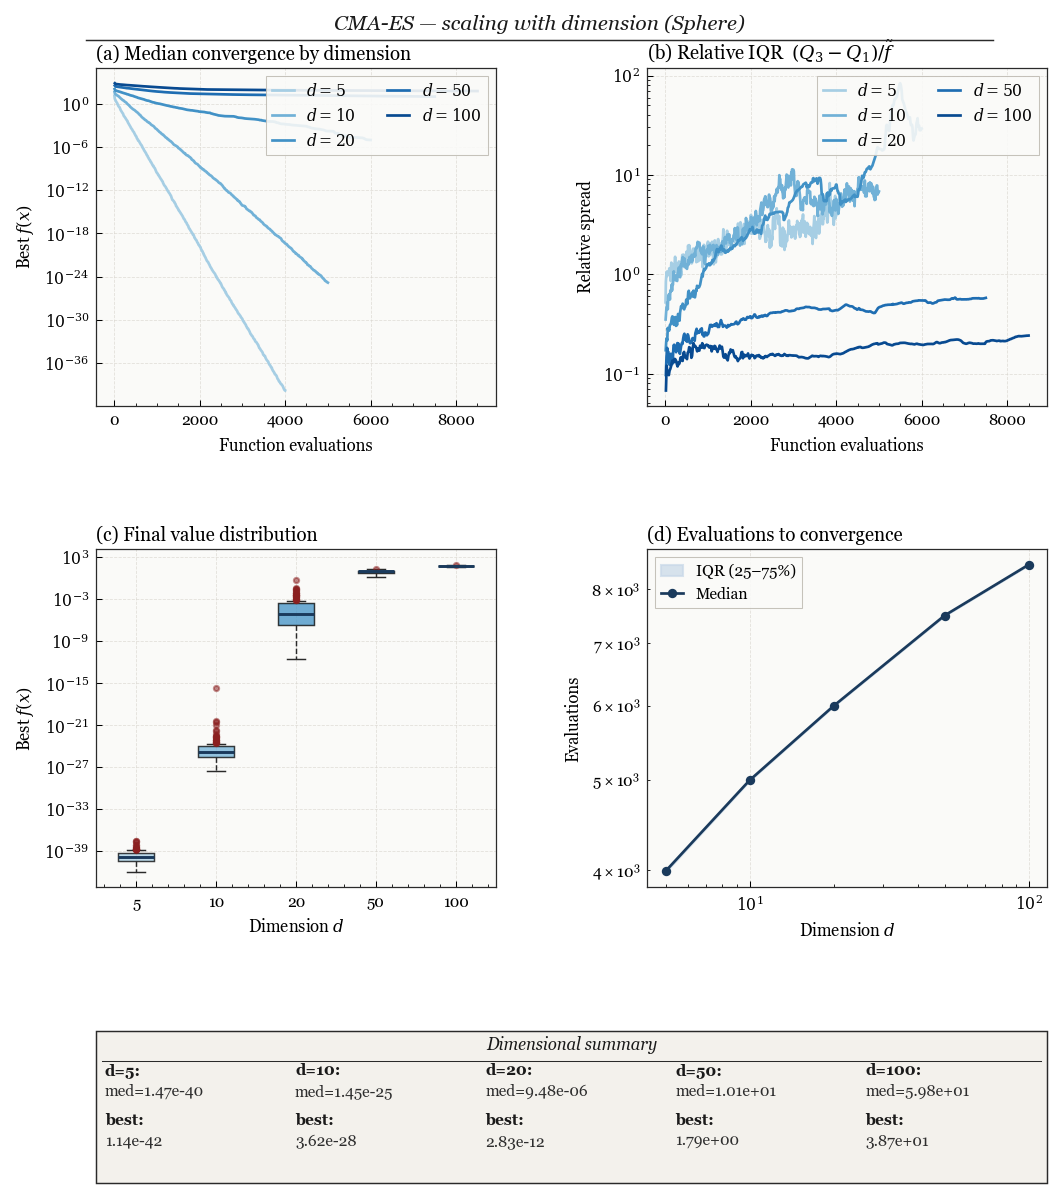

In [25]:
plot_painel_dimensional(hist_sphere, func='Sphere')

## Referências

<a id="ref-paper-original"></a> [1] Kennedy, J., & Eberhart, R. (1995). *Particle swarm optimization*. Proceedings of ICNN'95 - International Conference on Neural Networks, 4, 1942–1948. https://doi.org/10.1109/ICNN.1995.488968

<a id="ref-shi-eberhart"></a> [2] Shi, Y., & Eberhart, R. (1998). *A modified particle swarm optimizer*. Proceedings of IEEE World Congress on Computational Intelligence, 69–73. https://doi.org/10.1109/ICEC.1998.699146

<a id="ref-pyswarms"></a> [3] Miranda, L. J. V. (2018). *PySwarms: a research toolkit for Particle Swarm Optimization in Python*. Journal of Open Source Software, 3(21), 433. https://doi.org/10.21105/joss.00433

<a id="ref-library"></a> [4] [Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/levy.html)